In [323]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
import pickle
import os
path = os.getcwd()

from neurolib.models.alnSimp import ALNModelSimp
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [406]:
aln = ALNModelSimp()

aln.params.ext_exc_current = 1.
aln.params.ext_inh_current = 1.
#aln.params.sigmae = 2.

#aln.params.mufe_init = np.array( [aln.params.ext_exc_current] )
def setinit(mufe_st):
    aln.params.mufe_init = np.array( [mufe_st] )
    aln.params.rates_exc_init = np.array( [[0.0]])

mufe_start= 1.


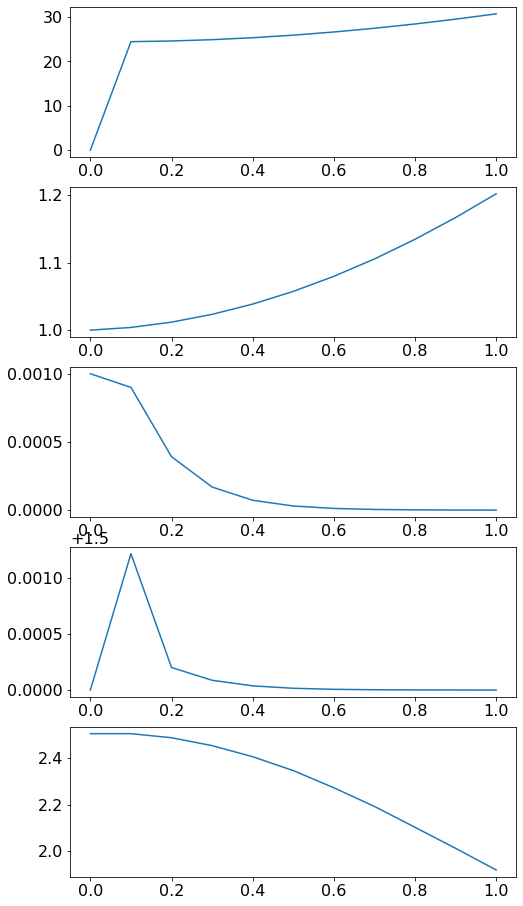

In [420]:
dur = 1.
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control0 = aln.getZeroControl()
target = aln.getZeroTarget()

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-16
incl_step = int(1. + aln.params.duration/aln.params.dt)
test_step = 1e-12

control1 = aln.getZeroControl()
control1[0,0,:] += np.sin(np.arange(0,dur+aln.params.dt,aln.params.dt))

#aln.params.cee = 0.
#aln.params.Ke = 0.
#aln.params.Jee = 1e-30

setinit(mufe_start)
aln.run(control=control1)

target[:,0,:] = aln.rates_exc[:,:]
#print(aln.rates_exc)
#print(aln.state["mufe"][0,:])
#print(aln.params.sigmae_ext)
#print(aln.state["tau_exc"][0,:])

fig, ax = plt.subplots(5, figsize=(8, 16))
ax[0].plot(aln.t, aln.rates_exc[0,:])
ax[1].plot(aln.t, aln.state["mufe"][0,:])
ax[2].plot(aln.t, aln.state["seev"][0,:])
ax[3].plot(aln.t, aln.state["sigmae_f"][0,:])
#ax[1,0].axhline(aln.params.ext_exc_current, aln.t[0], aln.t[-1], c="red", linestyle=":")
ax[4].plot(aln.t, aln.state["tau_exc"][0,:])

In [405]:
max_cntrl = 1000. * 5.
start_step = 100.
cost_params = [1.0, 0.0, 0.0]

setinit(mufe_start)
init_state_vars = np.array( [aln.rates_exc[0,0], mufe_start, mufi_start] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
#control2 += 2.

max_it = 10

A1_bestControlA, A1_bestStateA, A1_costA, runtime = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  1684.8987826807786
change bisection factor to  1.2
change bisection factor to  1.1
step size =  1.7639810314180537 631.2548853821797
RUN  1 , total integrated cost =  631.2548853821797
change bisection factor to  1.2
change bisection factor to  1.1
step size =  2.34785875281743 207.0855801633742
RUN  2 , total integrated cost =  207.0855801633742
change bisection factor to  1.2
change bisection factor to  1.1
step size =  1.0672085240079228 114.93393566499415
RUN  3 , total integrated cost =  114.93393566499415
change bisection factor to  1.2
change bisection factor to  1.1
step size =  2.5826446280991733 40.0478909178758
RUN  4 , total integrated cost =  40.0478909178758
change bisection factor to  1.2
change bisection factor to  1.1
step size =  0.60743148464809 27.535523032907783
RUN  5 , total integrated cost =  27.535523032907783
change bisection factor to  1.2
change bisection factor to  1.1
step size =  1.9403791345598593 21.5357

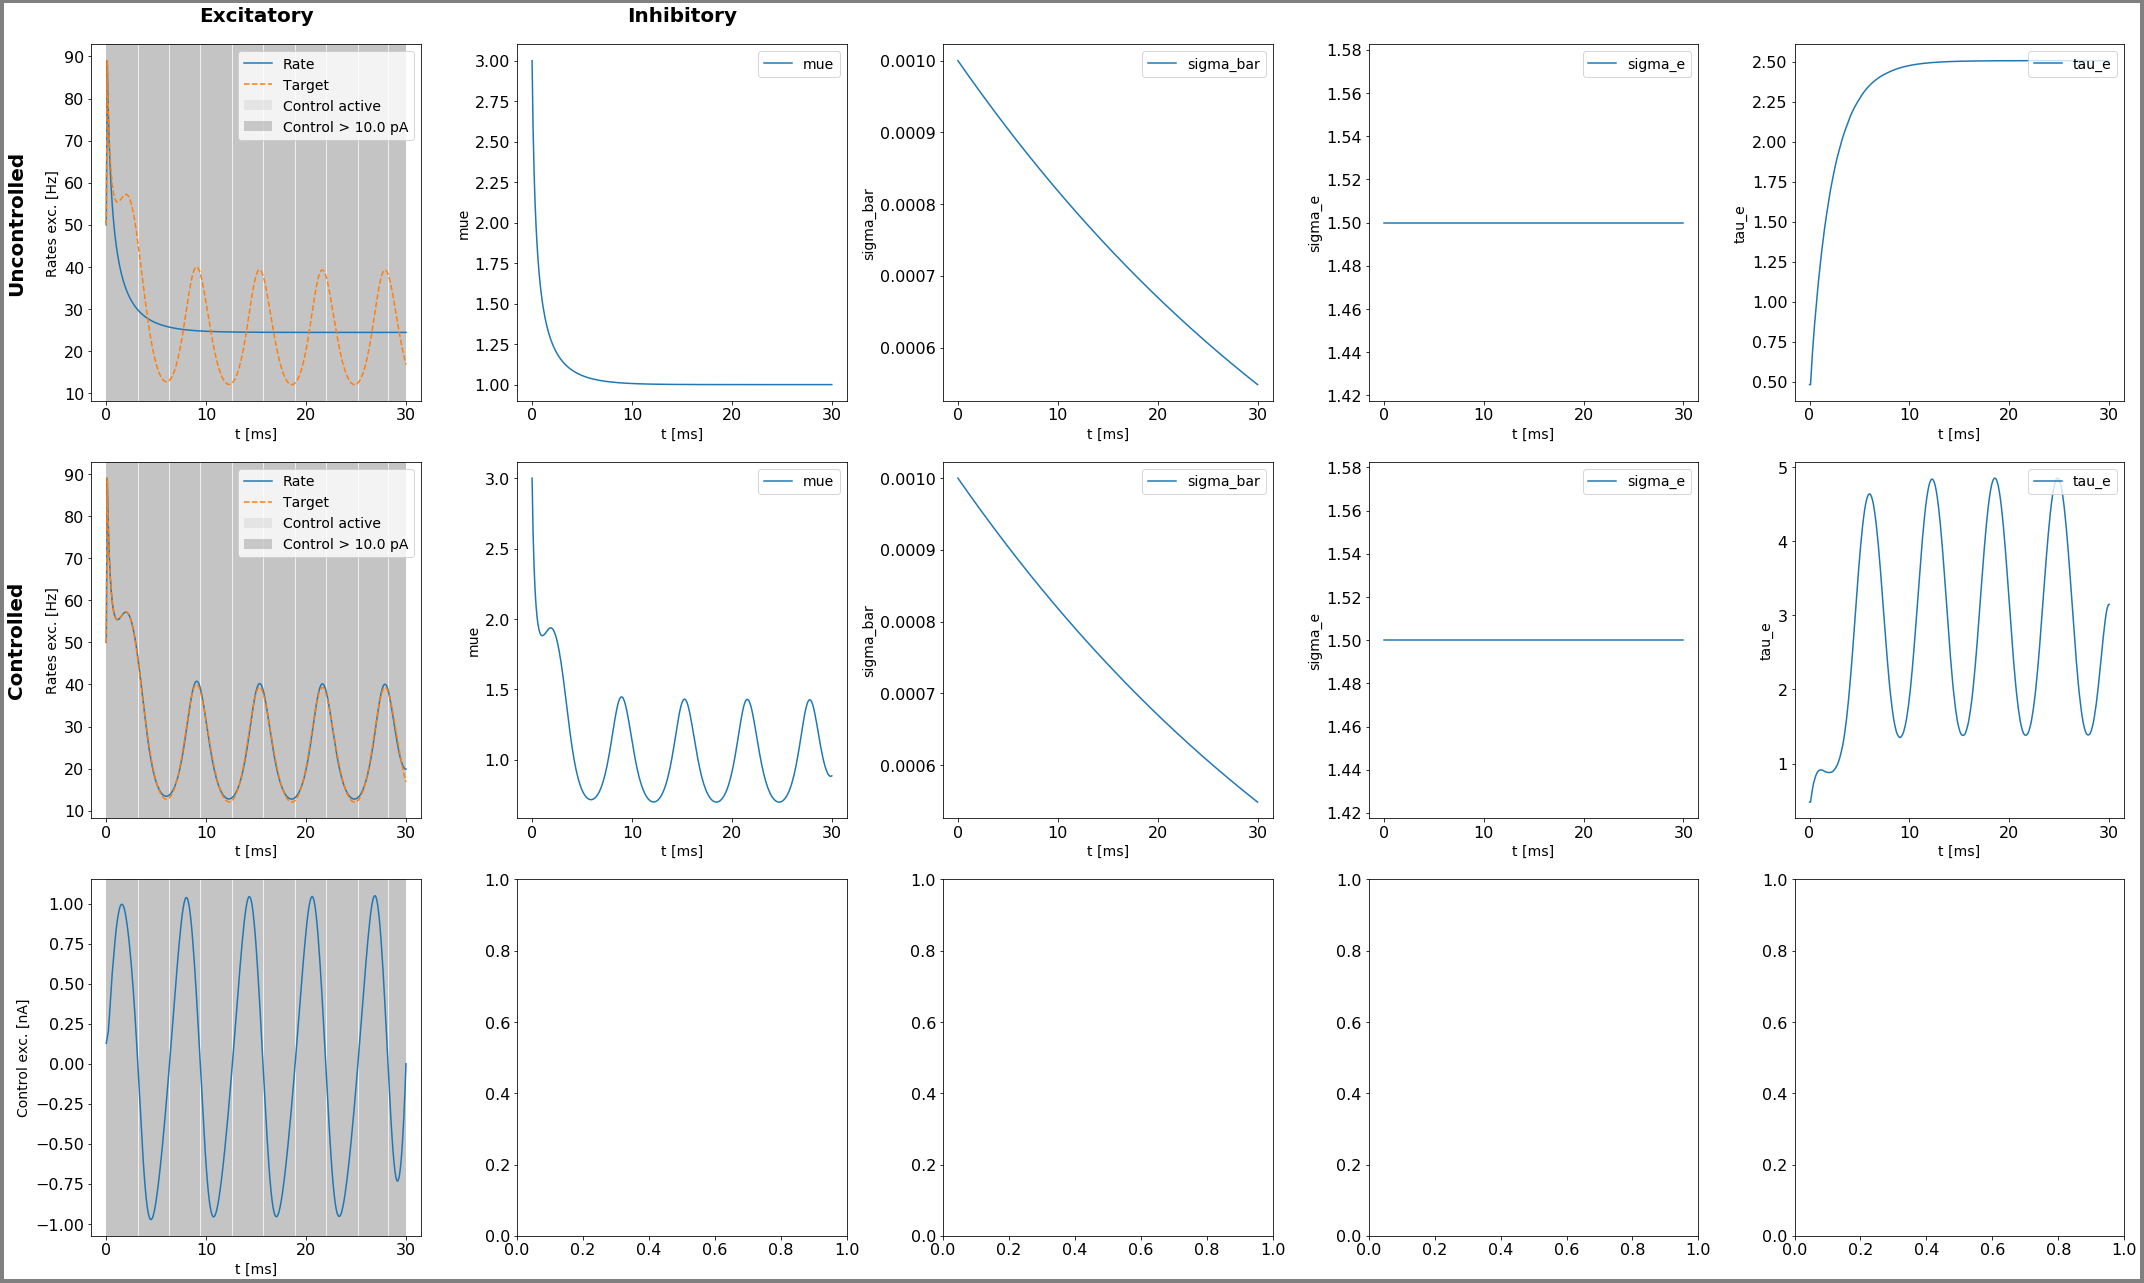

In [401]:
init_state_vars = np.array( [aln.rates_exc[0,0], mufe_start] )
plotFunc.plot_control(aln, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a1simp')

In [314]:
A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control2, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  14.243348342133544
change bisection factor to  1.01
change bisection factor to  1.01
change bisection factor to  1.01
RUN  1 , total integrated cost:  1.6186205055376388
change bisection factor to  1.01
change bisection factor to  1.01
change bisection factor to  1.01
RUN  2 , total integrated cost:  0.2653294112301855
change bisection factor to  1.01
change bisection factor to  1.01
change bisection factor to  1.01
RUN  3 , total integrated cost:  0.1572415673945955
change bisection factor to  1.01
change bisection factor to  1.01
change bisection factor to  1.01
RUN  4 , total integrated cost:  0.14866726425689014
change bisection factor to  1.01
change bisection factor to  1.01
change bisection factor to  1.01
RUN  5 , total integrated cost:  0.14815809531555962
change bisection factor to  1.01
change bisection factor to  1.01
change bisection factor to  1.01
RUN  6 , total integrated cost:  0.1481200259893676
change bisection factor t

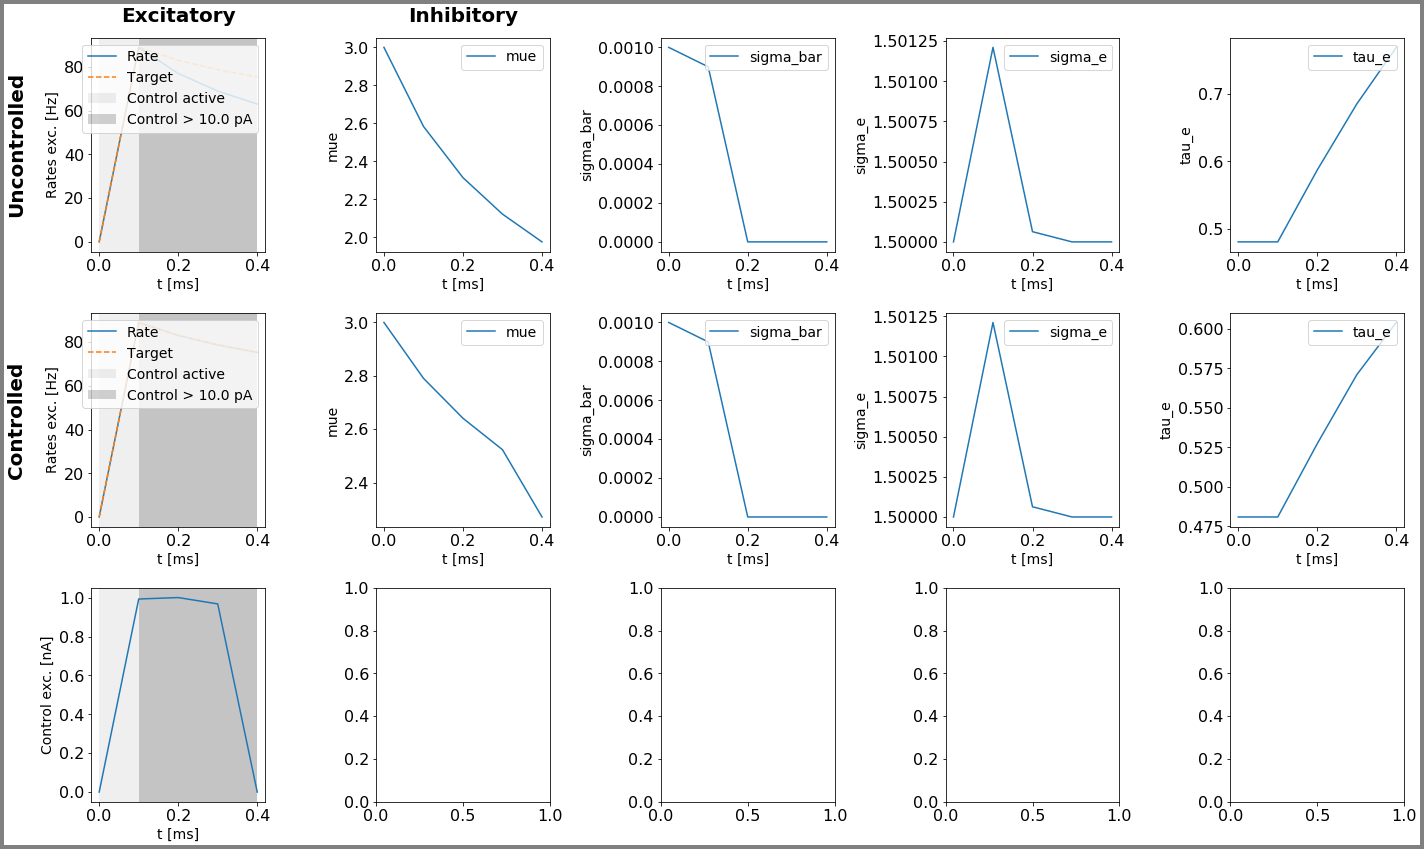

In [315]:
plotFunc.plot_control(aln, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

sigmarange =  0.5 5.0 64
rates range =  -1.0 7.0 350


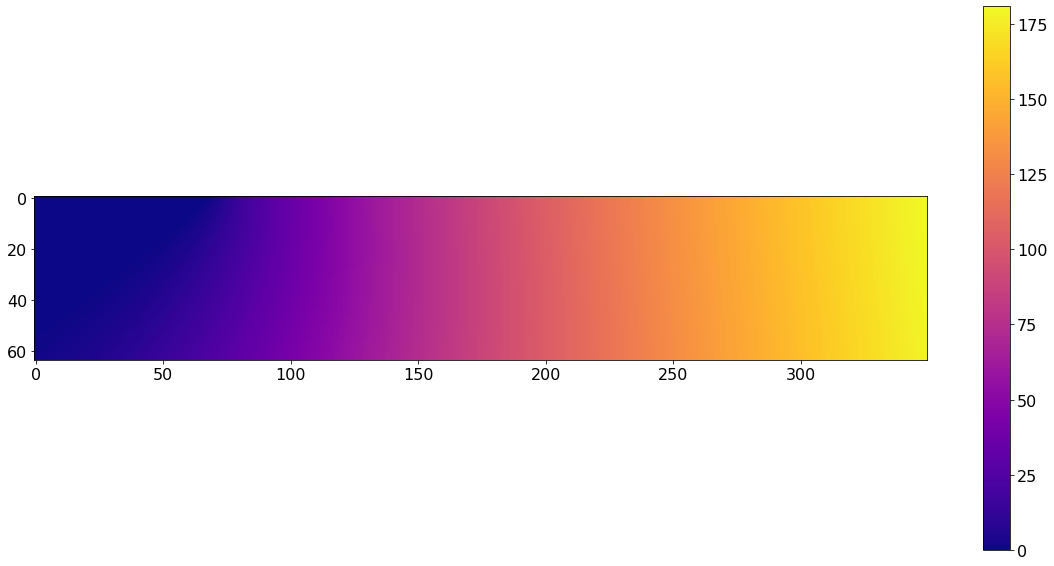

In [73]:
rates = aln.params.precalc_r * 1e3
print("sigmarange = ", aln.params.sigmarange[0], aln.params.sigmarange[-1], len(aln.params.sigmarange))
print("rates range = ", aln.params.Irange[0], aln.params.Irange[-1], len(aln.params.Irange))

plt.figure(figsize=(20,10))
plt.imshow(rates.T)
plt.colorbar()
plt.show()

(350, 64, 2)


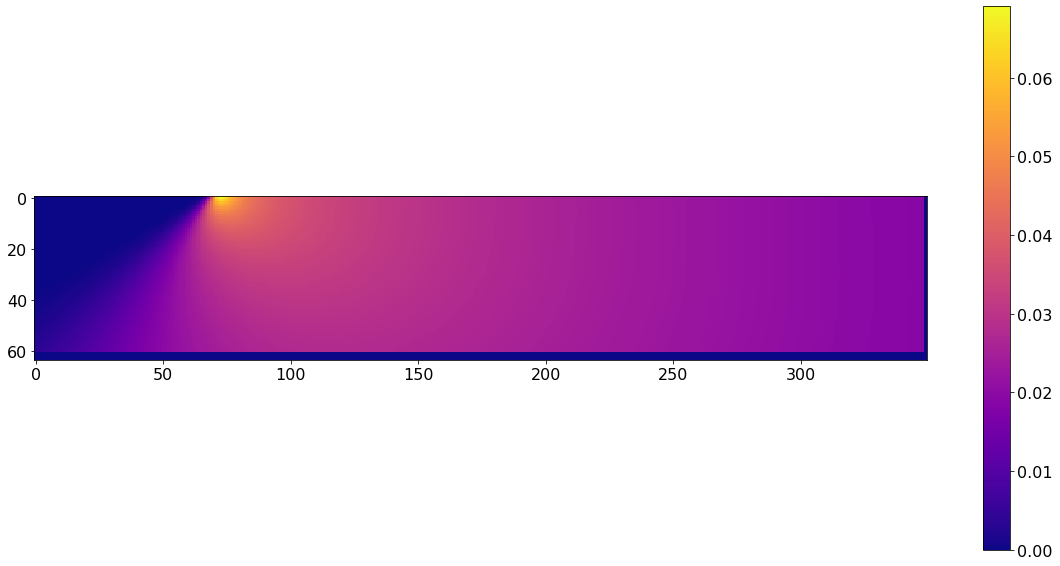

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


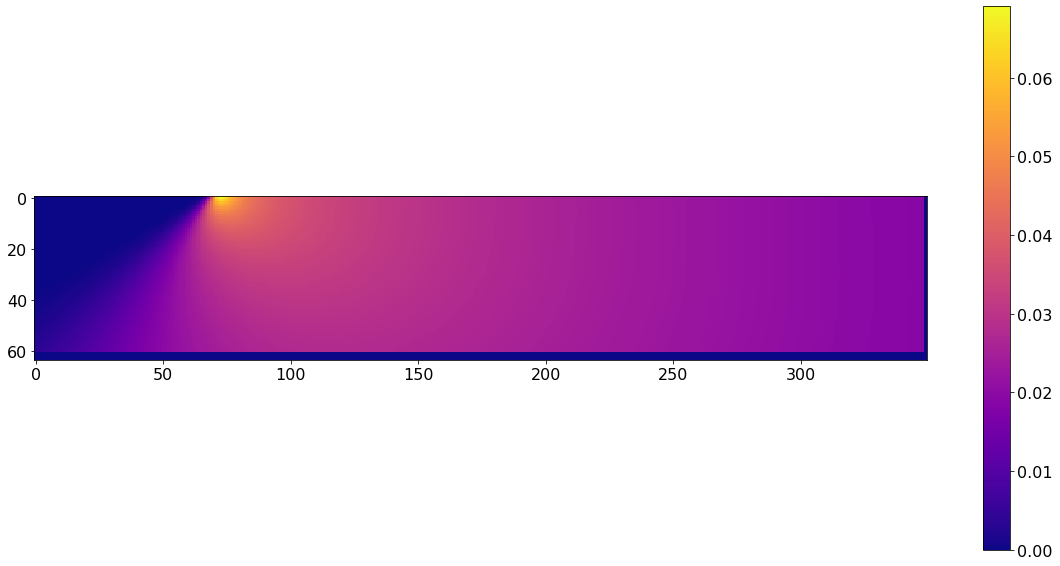

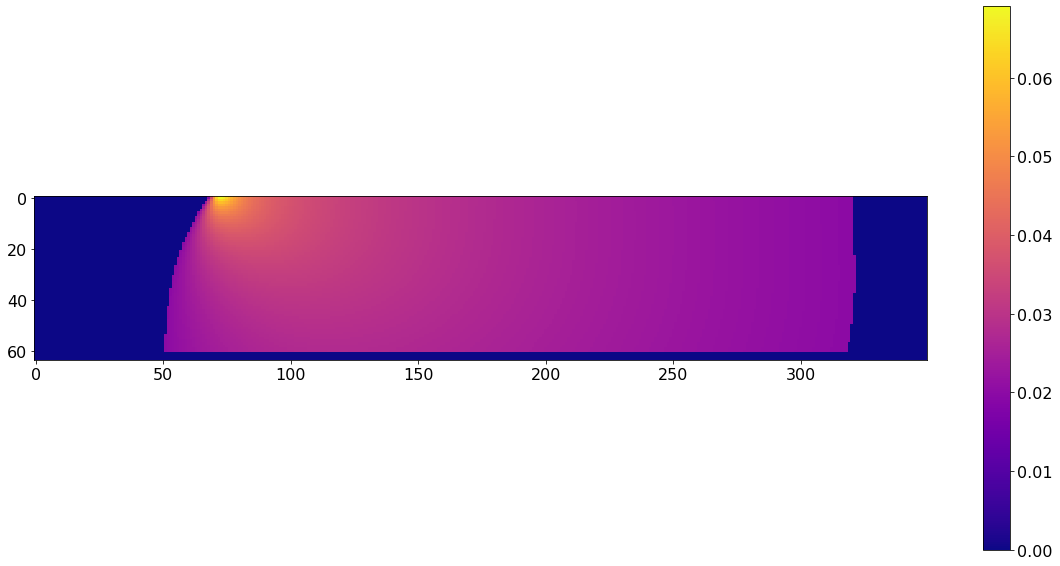

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()